In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pwd

'/Users/junchangsong/Downloads/Personal_Projects/Portfolio_web/data'

In [34]:
# Use sep='\t' because your file uses tabs instead of commas
df= pd.read_csv('EmployerInformation_v3.csv', sep='\t', encoding='utf-16')

# Check the first few rows
df.head()

/var/folders/__/9031fj2x7p1_0pmf50165l2c0000gn/T/ipykernel_95681/2328386231.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('EmployerInformation_v3.csv', sep='\t', encoding='utf-16')


,Line by line,Fiscal Year,Employer (Petitioner) Name,Tax ID,Industry (NAICS) Code,Petitioner City,Petitioner State,Petitioner Zip Code,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial
0,1,2026,NaN,4902.0,31-33 - Manufacturing,RANDOLPH,MA,2368.0,0,0,1,0,0,0,0,0,0,0,0,0
1,2,2026,NaN,9012.0,31-33 - Manufacturing,HILLSBOROUGH,NH,3244.0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,2026,1 EMC LLC,9142.0,72 - Accommodation and Food Services,FINDLAY,OH,45840.0,1,0,0,0,0,0,0,0,0,0,0,0
3,4,2026,1 NET SOFTWARE TECHNOLOGIES,9485.0,"54 - Professional, Scientific, and Technical S...",IRVING,TX,75063.0,0,0,0,0,0,0,0,0,0,0,1,0
4,5,2026,1-800-FLOWERS COM INC,7311.0,44-45 - Retail Trade,JERICHO,NY,11753.0,0,0,1,0,0,0,0,0,0,0,0,0


In [35]:
df['Fiscal Year   '].value_counts().reset_index().sort_values(by = "Fiscal Year   ", ascending = True)

,Fiscal Year,count
2,2023,57394
1,2024,61824
0,2025,62324
3,2026,24362


In [36]:
df.columns

Index(['Line by line', 'Fiscal Year   ', 'Employer (Petitioner) Name',
       'Tax ID', 'Industry (NAICS) Code', 'Petitioner City',
       'Petitioner State', 'Petitioner Zip Code', 'New Employment Approval',
       'New Employment Denial', 'Continuation Approval', 'Continuation Denial',
       'Change with Same Employer Approval',
       'Change with Same Employer Denial', 'New Concurrent Approval',
       'New Concurrent Denial', 'Change of Employer Approval',
       'Change of Employer Denial', 'Amended Approval', 'Amended Denial'],
      dtype='object')

In [37]:
# Trim whitespace from all column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Verify the fix
print(df.columns)

Index(['line_by_line', 'fiscal_year', 'employer_(petitioner)_name', 'tax_id',
       'industry_(naics)_code', 'petitioner_city', 'petitioner_state',
       'petitioner_zip_code', 'new_employment_approval',
       'new_employment_denial', 'continuation_approval', 'continuation_denial',
       'change_with_same_employer_approval',
       'change_with_same_employer_denial', 'new_concurrent_approval',
       'new_concurrent_denial', 'change_of_employer_approval',
       'change_of_employer_denial', 'amended_approval', 'amended_denial'],
      dtype='object')


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205904 entries, 0 to 205903
Data columns (total 20 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   line_by_line                        205904 non-null  object 
 1   fiscal_year                         205904 non-null  int64  
 2   employer_(petitioner)_name          205885 non-null  object 
 3   tax_id                              202897 non-null  float64
 4   industry_(naics)_code               197808 non-null  object 
 5   petitioner_city                     205904 non-null  object 
 6   petitioner_state                    205820 non-null  object 
 7   petitioner_zip_code                 205810 non-null  float64
 8   new_employment_approval             205904 non-null  object 
 9   new_employment_denial               205904 non-null  int64  
 10  continuation_approval               205904 non-null  object 
 11  continuation_denial       

| Field Name                         | Type    | Non-Null | Description                                                                   |
| ---------------------------------- | ------- | -------- | ----------------------------------------------------------------------------- |
| line_by_line                       | object  | 205,904  | Internal record identifier.                                                   |
| fiscal_year                        | int64   | 205,904  | The Federal Fiscal Year (Oct 1–Sept 30) of adjudication.                      |
| employer_(petitioner)name          | object  | 205,885  | Legal name of the firm or employer.                                           |
| tax_id                             | float64 | 202,897  | Last four digits of the Petitioner’s Tax ID.                                  |
| industry_(naics)code               | object  | 197,808  | 2-digit NAICS industry code (Code 99 = Unknown).                              |
| petitioner_city                    | object  | 205,904  | Employer's mailing address city.                                              |
| petitioner_state                   | object  | 205,820  | Employer's mailing address state.                                             |
| petitioner_zip_code                | float64 | 205,810  | Employer's mailing address 5-digit ZIP code.                                  |
| new_employment_approval            | object  | 205,904  | Approved workers for new H-1B employment (cap-subject or new classification). |
| new_employment_denial              | int64   | 205,904  | Denied workers for new H-1B employment.                                       |
| continuation_approval              | object  | 205,904  | Approved workers continuing current employment with same employer.            |
| continuation_denial                | int64   | 205,904  | Denied workers for continuing current employment.                             |
| change_with_same_employer_approval | object  | 205,904  | Approved non-material changes (e.g., job title) with same employer.           |
| change_with_same_employer_denial   | int64   | 205,904  | Denied non-material changes with same employer.                               |
| new_concurrent_approval            | int64   | 205,904  | Approved workers starting an additional concurrent H-1B job.                  |
| new_concurrent_denial              | int64   | 205,904  | Denied workers for additional concurrent H-1B employment.                     |
| change_of_employer_approval        | object  | 205,904  | Approved workers moving to a new employer.                                    |
| change_of_employer_denial          | int64   | 205,904  | Denied workers moving to a new employer.                                      |
| amended_approval                   | object  | 205,904  | Approved material changes to original petition terms.                         |
| amended_denial                     | int64   | 205,904  | Denied material changes to original petition terms.                           |

## First 5 rows

In [44]:
df.head()

,line_by_line,fiscal_year,employer_(petitioner)_name,tax_id,industry_(naics)_code,petitioner_city,petitioner_state,petitioner_zip_code,new_employment_approval,new_employment_denial,continuation_approval,continuation_denial,change_with_same_employer_approval,change_with_same_employer_denial,new_concurrent_approval,new_concurrent_denial,change_of_employer_approval,change_of_employer_denial,amended_approval,amended_denial
0,1,2026,NaN,4902.0,31-33 - Manufacturing,RANDOLPH,MA,2368.0,0,0,1,0,0,0,0,0,0,0,0,0
1,2,2026,NaN,9012.0,31-33 - Manufacturing,HILLSBOROUGH,NH,3244.0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,2026,1 EMC LLC,9142.0,72 - Accommodation and Food Services,FINDLAY,OH,45840.0,1,0,0,0,0,0,0,0,0,0,0,0
3,4,2026,1 NET SOFTWARE TECHNOLOGIES,9485.0,"54 - Professional, Scientific, and Technical S...",IRVING,TX,75063.0,0,0,0,0,0,0,0,0,0,0,1,0
4,5,2026,1-800-FLOWERS COM INC,7311.0,44-45 - Retail Trade,JERICHO,NY,11753.0,0,0,1,0,0,0,0,0,0,0,0,0


# H1B Approval and Denials changes by year

In [ ]:
# record count by fiscal year
df['fiscal_year'].value_counts().reset_index().sort_values(by = "fiscal_year", ascending = True)

,fiscal_year,count
2,2023,57394
1,2024,61824
0,2025,62324
3,2026,24362


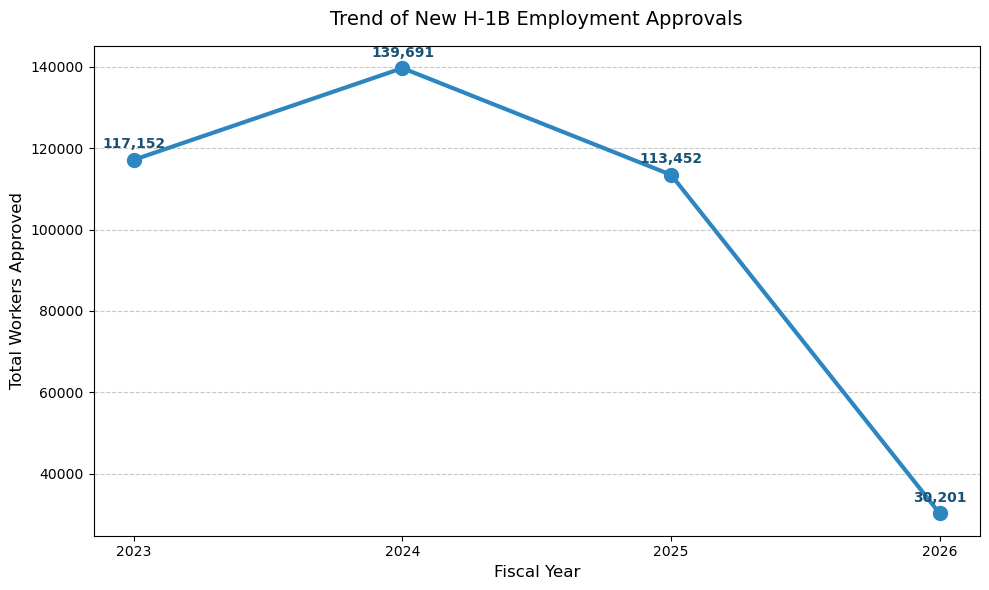

In [68]:
# 1. Clean the 'new_employment_approval' column
# We must remove commas and convert to numeric to sum the values
df['new_employment_approval_num'] = pd.to_numeric(
    df['new_employment_approval'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# 2. Group by fiscal year and SUM the approvals
yearly_approvals = df.groupby('fiscal_year')['new_employment_approval_num'].sum().reset_index()
yearly_approvals = yearly_approvals.sort_values('fiscal_year')

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# Plotting as a line with markers to show the trend
plt.plot(
    yearly_approvals['fiscal_year'].astype(str), 
    yearly_approvals['new_employment_approval_num'], 
    marker='o', 
    linewidth=3, 
    markersize=10, 
    color='#2e86c1', 
    label='New Approvals'
)

# Adding labels and styling
plt.title('Trend of New H-1B Employment Approvals', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=12)
plt.ylabel('Total Workers Approved', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels for each point
for i, val in enumerate(yearly_approvals['new_employment_approval_num']):
    plt.text(i, val + (yearly_approvals['new_employment_approval_num'].max() * 0.02), 
             f'{int(val):,}', ha='center', fontweight='bold', color='#1a5276')

plt.tight_layout()
plt.show()

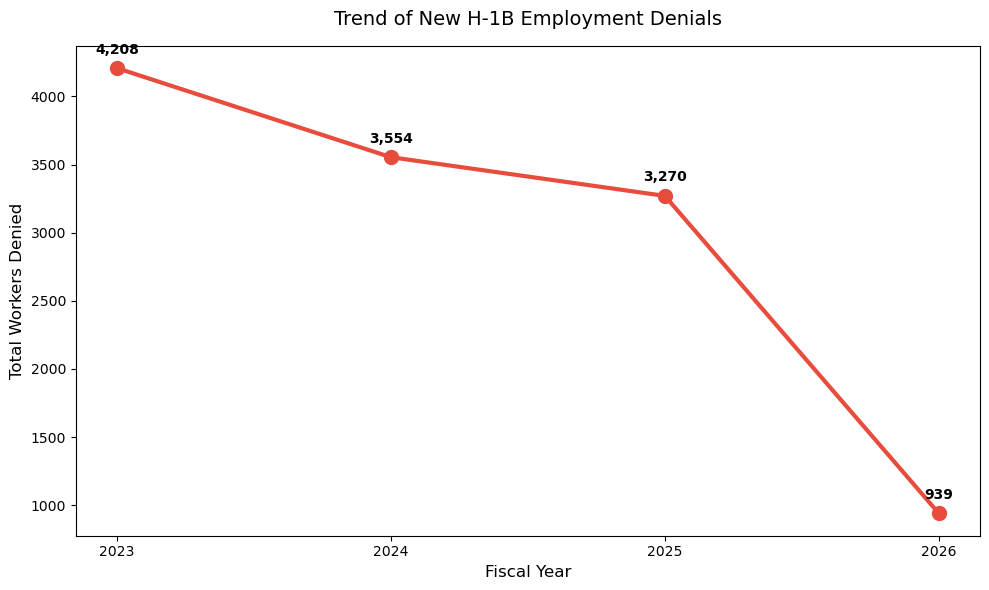

In [73]:
# 1. Group by fiscal year and SUM the denials
yearly_denials = df.groupby('fiscal_year')['new_employment_denial'].sum().reset_index()
yearly_denials = yearly_denials.sort_values('fiscal_year')

# 2. Create the Visualization
plt.figure(figsize=(10, 6))

# Plotting as a line chart (using red to indicate denials)
plt.plot(
    yearly_denials['fiscal_year'].astype(str), 
    yearly_denials['new_employment_denial'], 
    marker='o', 
    linewidth=3, 
    markersize=10, 
    color='#e74c3c', 
    label='New Denials'
)

# 3. Styling the chart
plt.title('Trend of New H-1B Employment Denials', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=12)
plt.ylabel('Total Workers Denied', fontsize=12)

# 4. Add data labels on top of each bar
for i, val in enumerate(yearly_denials['new_employment_denial']):
    plt.text(i, val + (yearly_denials['new_employment_denial'].max() * 0.02), 
             f'{int(val):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

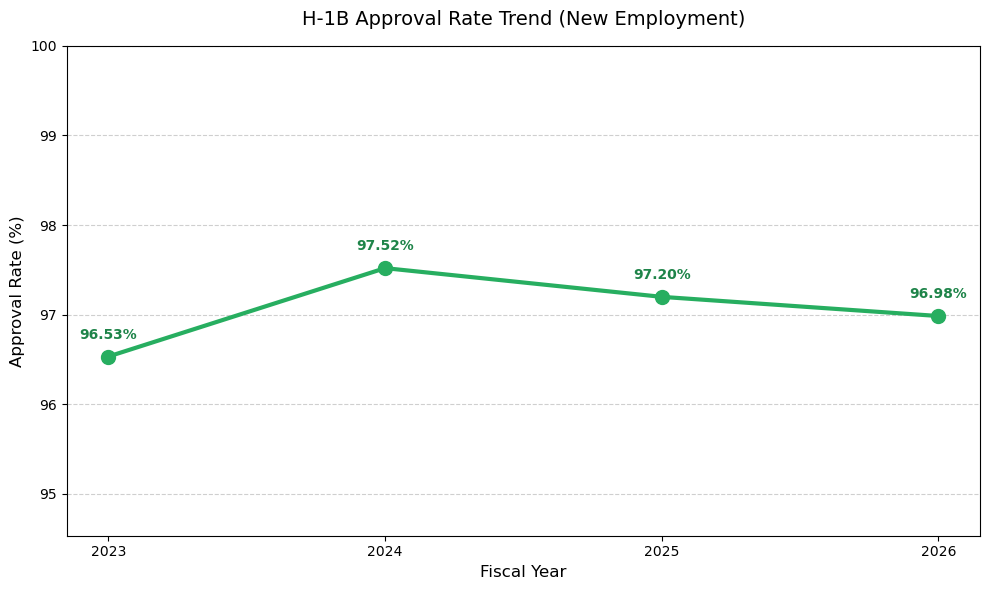

In [74]:
# 1. Clean the 'new_employment_approval' column: 
# Remove commas and convert to numeric so we can do math
df['new_employment_approval_num'] = pd.to_numeric(
    df['new_employment_approval'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# 2. Group by fiscal year and sum both approvals and denials
rate_df = df.groupby('fiscal_year').agg({
    'new_employment_approval_num': 'sum',
    'new_employment_denial': 'sum'
}).reset_index()

# 3. Calculate Approval Rate based on your formula
# Note: Multiplying by 100 for a percentage
rate_df['approval_rate'] = (
    rate_df['new_employment_approval_num'] / 
    (rate_df['new_employment_approval_num'] + rate_df['new_employment_denial'])
) * 100

# 4. Create the Visualization (Line Chart for Trends)
plt.figure(figsize=(10, 6))

plt.plot(
    rate_df['fiscal_year'].astype(str), 
    rate_df['approval_rate'], 
    marker='o', 
    linewidth=3, 
    markersize=10, 
    color='#27ae60'  # Green for approvals
)

# 5. Styling the chart
plt.title('H-1B Approval Rate Trend (New Employment)', fontsize=14, pad=15)
plt.xlabel('Fiscal Year', fontsize=12)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add percentage labels at each point
for i, val in enumerate(rate_df['approval_rate']):
    plt.text(i, val + 0.2, f'{val:.2f}%', ha='center', fontweight='bold', color='#1e8449')

# Adjust Y-axis to focus on the high percentage range
plt.ylim(min(rate_df['approval_rate']) - 2, 100)

plt.tight_layout()
plt.show()

In [51]:
# dropping null employer_(petitioner)_name 
df = df.dropna(subset=['employer_(petitioner)_name'])
df.head()

,line_by_line,fiscal_year,employer_(petitioner)_name,tax_id,industry_(naics)_code,petitioner_city,petitioner_state,petitioner_zip_code,new_employment_approval,new_employment_denial,continuation_approval,continuation_denial,change_with_same_employer_approval,change_with_same_employer_denial,new_concurrent_approval,new_concurrent_denial,change_of_employer_approval,change_of_employer_denial,amended_approval,amended_denial
2,3,2026,1 EMC LLC,9142.0,72 - Accommodation and Food Services,FINDLAY,OH,45840.0,1,0,0,0,0,0,0,0,0,0,0,0
3,4,2026,1 NET SOFTWARE TECHNOLOGIES,9485.0,"54 - Professional, Scientific, and Technical S...",IRVING,TX,75063.0,0,0,0,0,0,0,0,0,0,0,1,0
4,5,2026,1-800-FLOWERS COM INC,7311.0,44-45 - Retail Trade,JERICHO,NY,11753.0,0,0,1,0,0,0,0,0,0,0,0,0
5,6,2026,1FINITY AMERICAS INC,4286.0,"54 - Professional, Scientific, and Technical S...",DALLAS,TX,75252.0,0,0,2,0,0,0,0,0,1,0,0,0
6,7,2026,1LINK TECHNOLOGY LLC,874.0,"54 - Professional, Scientific, and Technical S...",GERMANTOWN,TN,38138.0,1,0,0,0,0,0,0,0,0,0,0,0


## H1b approval and denial by employers

In [56]:
df[df['employer_(petitioner)_name']== 'STATE UNIVERSITY OF NEW YORK AT BUFFALO'].head(10)

,line_by_line,fiscal_year,employer_(petitioner)_name,tax_id,industry_(naics)_code,petitioner_city,petitioner_state,petitioner_zip_code,new_employment_approval,new_employment_denial,continuation_approval,continuation_denial,change_with_same_employer_approval,change_with_same_employer_denial,new_concurrent_approval,new_concurrent_denial,change_of_employer_approval,change_of_employer_denial,amended_approval,amended_denial
19843,"19,844",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,ALBANY,NY,12222.0,1,0,0,0,0,0,0,0,0,0,0,0
19844,"19,845",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,BINGHAMTON,NY,13902.0,0,0,2,1,0,0,0,0,0,0,0,0
19845,"19,846",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,BROOKLYN,NY,11203.0,1,0,1,0,0,0,0,0,0,0,0,0
19846,"19,847",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,BUFFALO,NY,14222.0,0,0,1,0,0,0,0,0,0,0,0,0
19847,"19,848",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,MORRISVILLE,NY,13408.0,0,0,1,0,0,0,0,0,0,0,0,0
19848,"19,849",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,SARATOGA SPRINGS,NY,12866.0,0,1,0,0,0,0,0,0,0,0,0,0
19849,"19,850",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,STONY BROOK,NY,11794.0,1,0,4,0,0,0,0,0,0,0,0,0
19850,"19,851",2026,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,61 - Educational Services,UTICA,NY,13502.0,4,0,2,0,0,0,0,0,0,0,0,0
75527,"75,528",2025,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,NaN,BINGHAMTON,NY,13902.0,1,0,1,0,0,0,0,0,0,0,0,0
75528,"75,529",2025,STATE UNIVERSITY OF NEW YORK AT BUFFALO,3200.0,NaN,BRONX,NY,10461.0,0,0,0,0,0,0,0,0,0,0,1,0


In [60]:
# 1. Clean the 'new_employment_approval' column: 
# Remove commas, convert to numeric, and fill missing values with 0
df['new_employment_approval'] = pd.to_numeric(
    df['new_employment_approval'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0).astype(int)

# 2. Group by year and employer, then sum the approvals
new_approvals_summary = (
    df.groupby(['fiscal_year', 'employer_(petitioner)_name'])['new_employment_approval']
    .sum()
    .reset_index()
)

# 3. Sort by fiscal year and the highest number of approvals for better visibility
new_approvals_summary = new_approvals_summary.sort_values(
    by=['fiscal_year', 'new_employment_approval'], 
    ascending=[True, False]
)

# Display the top results
new_approvals_summary.head(10)

,fiscal_year,employer_(petitioner)_name,new_employment_approval
2351,2023,AMAZON.COM SERVICES LLC,2814
9703,2023,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,2579
21200,2023,INFOSYS LIMITED,2144
17990,2023,GOOGLE LLC,1263
41342,2023,TATA CONSULTANCY SVCS LTD,1167
7595,2023,CAPGEMINI AMERICA INC,1108
27479,2023,MICROSOFT CORPORATION,987
20438,2023,IBM CORPORATION,979
47386,2023,WIPRO LIMITED,971
27230,2023,META PLATFORMS INC,733


In [61]:
import plotly.graph_objects as go

# 1. Prepare the data (assuming new_approvals_summary is already created)
# Ensure data is sorted for the top 10 per year
years = sorted(new_approvals_summary['fiscal_year'].unique())
fig = go.Figure()

# 2. Add a 'Trace' (bar set) for each year
for year in years:
    year_data = new_approvals_summary[new_approvals_summary['fiscal_year'] == year]
    top_10 = year_data.nlargest(10, 'new_employment_approval').sort_values('new_employment_approval', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=top_10['employer_(petitioner)_name'],
            x=top_10['new_employment_approval'],
            name=str(year),
            orientation='h',
            visible=(year == years[0]), # Only the first year is visible by default
            marker=dict(color='#5dade2'),
            text=top_10['new_employment_approval'],
            textposition='auto',
        )
    )

# 3. Create the update buttons
buttons = []
for i, year in enumerate(years):
    # 'visible' list needs to be [True, False, False...] depending on which trace to show
    visibility = [False] * len(years)
    visibility[i] = True
    
    button = dict(
        label=str(year),
        method="update",
        args=[{"visible": visibility},
              {"title": f"Top 10 Employers for New H-1B Approvals: {year}"}]
    )
    buttons.append(button)

# 4. Update layout with the dropdown menu
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        ),
    ],
    title=f"Top 10 Employers for New H-1B Approvals: {years[0]}",
    xaxis_title="Number of Approvals",
    yaxis_title="Employer Name",
    height=600,
    margin=dict(l=200, r=20, t=100, b=50),
    template="plotly_white"
)

fig.show()

In [75]:
# 1. Prepare the Denial Summary Data
# Group by year and employer, summing the denial counts
new_denials_summary = (
    df.groupby(['fiscal_year', 'employer_(petitioner)_name'])['new_employment_denial']
    .sum()
    .reset_index()
)

years = sorted(new_denials_summary['fiscal_year'].unique())
fig = go.Figure()

# 2. Add a 'Trace' (bar set) for each year
for year in years:
    year_data = new_denials_summary[new_denials_summary['fiscal_year'] == year]
    
    # Get top 10 employers with the most denials for that year
    top_10_denials = year_data.nlargest(10, 'new_employment_denial').sort_values('new_employment_denial', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=top_10_denials['employer_(petitioner)_name'],
            x=top_10_denials['new_employment_denial'],
            name=str(year),
            orientation='h',
            visible=(year == years[0]),  # Only show the first year by default
            marker=dict(color='#e74c3c'), # Using Red to represent denials
            text=top_10_denials['new_employment_denial'],
            textposition='auto',
        )
    )

# 3. Create the update buttons for the dropdown menu
buttons = []
for i, year in enumerate(years):
    visibility = [False] * len(years)
    visibility[i] = True
    
    button = dict(
        label=str(year),
        method="update",
        args=[{"visible": visibility},
              {"title": f"Top 10 Employers for New H-1B Denials: {year}"}]
    )
    buttons.append(button)

# 4. Update layout with the dropdown and styling
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        ),
    ],
    title=f"Top 10 Employers for New H-1B Denials: {years[0]}",
    xaxis_title="Number of Denials",
    yaxis_title="Employer Name",
    height=600,
    margin=dict(l=250, r=20, t=100, b=50),
    template="plotly_white"
)

fig.show()

In [79]:
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare and Clean Data
# Convert approvals to numeric (handling commas)
df['new_employment_approval_num'] = pd.to_numeric(
    df['new_employment_approval'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# Group by year and employer, summing both metrics
employer_summary = df.groupby(['fiscal_year', 'employer_(petitioner)_name']).agg({
    'new_employment_approval_num': 'sum',
    'new_employment_denial': 'sum'
}).reset_index()

# 2. Calculate Approval Rate (%)
# Formula: Approvals / (Approvals + Denials)
employer_summary['total_petitions'] = employer_summary['new_employment_approval_num'] + employer_summary['new_employment_denial']

# We filter for employers with a minimum number of petitions (e.g., 5) 
# to avoid 100% rates from single-petition employers skewing the "Top 10"
min_petitions = 10
filtered_summary = employer_summary[employer_summary['total_petitions'] >= min_petitions].copy()

filtered_summary['approval_rate'] = (
    filtered_summary['new_employment_approval_num'] / filtered_summary['total_petitions']
) * 100

# 3. Create the Interactive Plot
years = sorted(filtered_summary['fiscal_year'].unique())
fig = go.Figure()

for year in years:
    year_data = filtered_summary[filtered_summary['fiscal_year'] == year]
    
    # Get top 10 employers by Approval Rate
    top_10 = year_data.nlargest(10, 'approval_rate').sort_values('approval_rate', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=top_10['employer_(petitioner)_name'],
            x=top_10['approval_rate'],
            name=str(year),
            orientation='h',
            visible=(year == years[0]),
            marker=dict(color='#27ae60'), # Green theme for success rates
            text=top_10['approval_rate'].apply(lambda x: f"{x:.1f}%"),
            textposition='auto',
            hovertemplate="<b>%{y}</b><br>Approval Rate: %{x:.2f}%<br><extra></extra>"
        )
    )

# 4. Create Dropdown Buttons
buttons = []
for i, year in enumerate(years):
    visibility = [False] * len(years)
    visibility[i] = True
    buttons.append(dict(
        label=str(year),
        method="update",
        args=[{"visible": visibility},
              {"title": f"Top 10 Employer Approval Rates: {year} (Min. {min_petitions} Petitions)"}]
    ))

# 5. Final Layout
fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True, x=0.1, y=1.15)],
    title=f"Top 10 Employer Approval Rates: {years[0]} (Min. {min_petitions} Petitions)",
    xaxis_title="Approval Rate (%)",
    yaxis_title="Employer Name",
    xaxis=dict(range=[0, 105]), # Fix axis from 0 to 100%
    height=600,
    margin=dict(l=250, r=20, t=100, b=50),
    template="plotly_white"
)

fig.show()

In [81]:
# 1. Prepare and Clean Data
# Convert approvals to numeric if not already done
df['new_employment_approval_num'] = pd.to_numeric(
    df['new_employment_approval'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# Group by year and NAICS code
industry_summary = df.groupby(['fiscal_year', 'industry_(naics)_code']).agg({
    'new_employment_approval_num': 'sum',
    'new_employment_denial': 'sum'
}).reset_index()

# 2. Calculate Approval Rate (%)
industry_summary['total_petitions'] = (
    industry_summary['new_employment_approval_num'] + 
    industry_summary['new_employment_denial']
)

# Calculate the rate
industry_summary['approval_rate'] = (
    industry_summary['new_employment_approval_num'] / 
    industry_summary['total_petitions']
) * 100

# 3. Create the Interactive Plot
years = sorted(industry_summary['fiscal_year'].unique())
fig = go.Figure()

for year in years:
    year_data = industry_summary[industry_summary['fiscal_year'] == year]
    
    # Get top 10 industries by Approval Rate
    # Note: We sort by approval_rate to see the most successful sectors
    top_10 = year_data.nlargest(10, 'approval_rate').sort_values('approval_rate', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=top_10['industry_(naics)_code'].astype(str),
            x=top_10['approval_rate'],
            name=str(year),
            orientation='h',
            visible=(year == years[0]),
            marker=dict(color='#8e44ad'), # Purple theme for industry sector analysis
            text=top_10['approval_rate'].apply(lambda x: f"{x:.2f}%"),
            textposition='auto',
            hovertemplate="<b>Industry Code: %{y}</b><br>Approval Rate: %{x:.2f}%<br>Total Petitions: %{customdata}<extra></extra>",
            customdata=top_10['total_petitions']
        )
    )

# 4. Create Dropdown Buttons
buttons = []
for i, year in enumerate(years):
    visibility = [False] * len(years)
    visibility[i] = True
    buttons.append(dict(
        label=str(year),
        method="update",
        args=[{"visible": visibility},
              {"title": f"Top 10 Industry Approval Rates: {year}"}]
    ))

# 5. Final Layout
fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True, x=0.1, y=1.15)],
    title=f"Top 10 Industry Approval Rates: {years[0]}",
    xaxis_title="Approval Rate (%)",
    yaxis_title="NAICS Industry Code",
    xaxis=dict(range=[0, 105]), # Fix axis to 100%
    height=600,
    margin=dict(l=200, r=20, t=100, b=50),
    template="plotly_white"
)

fig.show()

In [76]:
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare the Industry Summary Data
# Ensure numeric conversion for approvals (if not already done)
df['new_employment_approval_num'] = pd.to_numeric(
    df['new_employment_approval'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# Group by year and NAICS code
industry_summary = (
    df.groupby(['fiscal_year', 'industry_(naics)_code'])['new_employment_approval_num']
    .sum()
    .reset_index()
)

years = sorted(industry_summary['fiscal_year'].unique())
fig = go.Figure()

# 2. Add a 'Trace' (bar set) for each year
for year in years:
    year_data = industry_summary[industry_summary['fiscal_year'] == year]
    
    # Get top 10 industries by approval count
    top_10_industries = year_data.nlargest(10, 'new_employment_approval_num').sort_values('new_employment_approval_num', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=top_10_industries['industry_(naics)_code'],
            x=top_10_industries['new_employment_approval_num'],
            name=str(year),
            orientation='h',
            visible=(year == years[0]), # First year visible by default
            marker=dict(color='#af7ac5'), # Purple theme for industry data
            text=top_10_industries['new_employment_approval_num'].apply(lambda x: f"{int(x):,}"),
            textposition='auto',
        )
    )

# 3. Create dropdown buttons
buttons = []
for i, year in enumerate(years):
    visibility = [False] * len(years)
    visibility[i] = True
    
    button = dict(
        label=str(year),
        method="update",
        args=[{"visible": visibility},
              {"title": f"Top 10 Industries for New H-1B Approvals: {year}"}]
    )
    buttons.append(button)

# 4. Update layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        ),
    ],
    title=f"Top 10 Industries for New H-1B Approvals: {years[0]}",
    xaxis_title="Total Workers Approved",
    yaxis_title="Industry (NAICS) Code",
    height=600,
    margin=dict(l=300, r=20, t=100, b=50),
    template="plotly_white"
)

fig.show()

In [ ]:
# 1. Prepare the Industry Summary Data
# Ensure numeric conversion for approvals (if not already done)
df['new_employment_denial_num'] = pd.to_numeric(
    df['new_employment_denial'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# Group by year and NAICS code
industry_summary = (
    df.groupby(['fiscal_year', 'industry_(naics)_code'])['new_employment_denial_num']
    .sum()
    .reset_index()
)

years = sorted(industry_summary['fiscal_year'].unique())
fig = go.Figure()

# 2. Add a 'Trace' (bar set) for each year
for year in years:
    year_data = industry_summary[industry_summary['fiscal_year'] == year]
    
    # Get top 10 industries by denial count
    top_10_industries = year_data.nlargest(10, 'new_employment_denial_num').sort_values('new_employment_denial_num', ascending=True)
    
    fig.add_trace(
        go.Bar(
            y=top_10_industries['industry_(naics)_code'],
            x=top_10_industries['new_employment_denial_num'],
            name=str(year),
            orientation='h',
            visible=(year == years[0]), # First year visible by default
            marker=dict(color='#af7ac5'), # Purple theme for industry data
            text=top_10_industries['new_employment_denial_num'].apply(lambda x: f"{int(x):,}"),
            textposition='auto',
        )
    )

# 3. Create dropdown buttons
buttons = []
for i, year in enumerate(years):
    visibility = [False] * len(years)
    visibility[i] = True
    
    button = dict(
        label=str(year),
        method="update",
        args=[{"visible": visibility},
              {"title": f"Top 10 Industries for New H-1B Approvals: {year}"}]
    )
    buttons.append(button)

# 4. Update layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        ),
    ],
    title=f"Top 10 Industries for New H-1B Denials: {years[0]}",
    xaxis_title="Total Workers Denied",
    yaxis_title="Industry (NAICS) Code",
    height=600,
    margin=dict(l=300, r=20, t=100, b=50),
    template="plotly_white"
)

fig.show()

In [65]:
# Search for any employer name containing 'lexis' (case-insensitive)
lexis_employers = df[df['employer_(petitioner)_name'].str.contains('lexis', case=False, na=False)]

# View the unique names found and their total approvals
lexis_summary = lexis_employers.groupby('employer_(petitioner)_name')['new_employment_approval'].sum().reset_index()
print(lexis_summary)

             employer_(petitioner)_name  new_employment_approval
0             ALEXIS CALDERA DESIGN LLC                        1
1       DELEXIS HEALTHCARE SOLUTION LLC                        1
2                         FLEXISPOT INC                        2
3                          FLEXISUS INC                        0
4     LEXISNEXIS COPLOGIC SOLUTIONS INC                        0
5   LEXISNEXIS RISK DATA MANAGEMENT INC                        0
6   LEXISNEXIS RISK DATA MANAGEMENT LLC                       12
7      LEXISNEXIS RISK SOLUTIONS FL INC                       26
8         LEXISNEXIS RISK SOLUTIONS INC                       43
9                        LEXISNEXIS USA                       19
10     LEXISNEXIS VITALCHEK NETWORK INC                        0
11        RELX INC D B A LEXISNEXIS USA                       73
12            STELEXIS THERAPEUTICS LLC                        0


In [66]:
import pandas as pd
import plotly.graph_objects as go
from ipywidgets import interact, widgets

# 1. Pre-process the data (Cleaning numeric columns)
df['new_employment_approval'] = pd.to_numeric(
    df['new_employment_approval'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# 2. Pre-aggregate data to make the widget fast
# We sum approvals by year and employer
trend_data = df.groupby(['fiscal_year', 'employer_(petitioner)_name'])['new_employment_approval'].sum().reset_index()

# 3. Define the plotting function
def plot_employer_trend(search_term):
    if len(search_term) < 3:
        print("Please type at least 3 characters to search for an employer...")
        return

    # Filter employers based on search term
    matches = trend_data[trend_data['employer_(petitioner)_name'].str.contains(search_term, case=False, na=False)]
    unique_matches = matches['employer_(petitioner)_name'].unique()

    if len(unique_matches) == 0:
        print(f"No employers found matching '{search_term}'")
        return
    
    # For this visualization, we'll pick the top match or allow multiple 
    # Here we show the trend for the first match found
    selected_employer = unique_matches[0]
    plot_df = matches[matches['employer_(petitioner)_name'] == selected_employer].sort_values('fiscal_year')

    # Create the Plotly figure
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=plot_df['fiscal_year'], 
        y=plot_df['new_employment_approval'],
        mode='lines+markers',
        line=dict(color='#2e86c1', width=3),
        marker=dict(size=10),
        name=selected_employer
    ))

    fig.update_layout(
        title=dict(text=f"H-1B Approval Trend: {selected_employer}", x=0.5),
        xaxis=dict(title="Fiscal Year", tickmode='linear'),
        yaxis=dict(title="New Approvals"),
        template="plotly_white",
        hovermode="x unified"
    )
    
    print(f"Showing results for: {selected_employer}")
    if len(unique_matches) > 1:
        print(f"(Also found: {', '.join(unique_matches[1:5])}...)")
        
    fig.show()

# 4. Create the interactive search box
interact(plot_employer_trend, search_term=widgets.Text(
    value='lexis',
    placeholder='Type employer name...',
    description='Employer:',
    continuous_update=False
));

interactive(children=(Text(value='lexis', continuous_update=False, description='Employer:', placeholder='Type …

In [39]:
df['amended_approval'].value_counts()

amended_approval
0      165477
1       23828
2        6039
3        2872
4        1716
        ...  
243         1
293         1
425         1
429         1
831         1
Name: count, Length: 245, dtype: int64

In [23]:
# Check types                           
types = df.iloc[:,0].apply(type).value_counts()               
print('\nType Distribution in Column 16:')                                       
print(types)    


Type Distribution in Column 16:
Line by line
<class 'str'>    205904
Name: count, dtype: int64


In [30]:
# Find mixed rows                       
# Often it is a mix of float (NaNs) and strings, or integers and strings         
main_type = types.idxmax()              
problematic = df[df.iloc[:, 0].apply(lambda x: type(x) != main_type)]   
                                            
if not problematic.empty:               
    print('\nSample problematic rows (different from majority type):')           
    print(problematic.head(10))         
else:                                   
    print('\nNo rows differ from the majority type after low_memory=False. This suggests the mix is subtly handled or consistent within the column but triggering the warning due to chunking.')  


No rows differ from the majority type after low_memory=False. This suggests the mix is subtly handled or consistent within the column but triggering the warning due to chunking.


SyntaxError: invalid syntax (3609840628.py, line 1)

In [22]:
df2.columns = df2.columns.str.strip()

In [23]:
df2.columns

Index(['Line by line', 'Fiscal Year', 'Employer (Petitioner) Name', 'Tax ID',
       'Industry (NAICS) Code', 'Petitioner City', 'Petitioner State',
       'Petitioner Zip Code', 'New Employment Approval',
       'New Employment Denial', 'Continuation Approval', 'Continuation Denial',
       'Change with Same Employer Approval',
       'Change with Same Employer Denial', 'New Concurrent Approval',
       'New Concurrent Denial', 'Change of Employer Approval',
       'Change of Employer Denial', 'Amended Approval', 'Amended Denial'],
      dtype='object')

In [24]:
df2['Fiscal Year'].value_counts().reset_index()

,Fiscal Year,count
0,2019,62379
1,2025,62324
2,2024,61824
3,2022,59631
4,2020,58928
5,2023,57394
6,2021,56260
7,2026,24362


In [27]:
df2.groupby(['Fiscal Year', 'Industry (NAICS) Code'])['Fiscal Year'].value_counts().reset_index()

,Fiscal Year,Industry (NAICS) Code,count
0,2019,"11 - Agriculture, Forestry, Fishing and Hunting",128
1,2019,"21 - Mining, Quarrying, and Oil and Gas Extrac...",291
2,2019,22 - Utilities,352
3,2019,23 - Construction,1121
4,2019,31-33 - Manufacturing,7384
...,...,...,...
155,2026,62 - Health Care and Social Assistance,1642
156,2026,"71 - Arts, Entertainment, and Recreation",113
157,2026,72 - Accommodation and Food Services,215
158,2026,81 - Other Services (except Public Administrat...,294


In [28]:
import plotly.express as px

# 1. Clean the data (Using the more efficient .size() method)
df_counts = df2.groupby(['Fiscal Year', 'Industry (NAICS) Code']).size().reset_index(name='count')

# 2. Create the interactive Stacked Bar Chart
fig = px.bar(
    df_counts, 
    x="Fiscal Year", 
    y="count", 
    color="Industry (NAICS) Code",
    title="H-1B Petitions by Industry Over Time",
    labels={"count": "Number of Petitions", "Fiscal Year": "Year"},
    barmode="stack", # Change to "group" for side-by-side bars
    template="plotly_dark" # Matches your Solarized/Dark theme
)

# 3. Improve the layout
fig.update_layout(
    legend_title_text='Industry',
    xaxis={'type': 'category'}, # Ensures years are treated as labels, not numbers
    hovermode="x unified" # Shows all industries for a year in one hover tooltip
)

st.plotly_chart(fig, use_container_width=True)

NameError: name 'st' is not defined